# Smart Lender - Loan Approval Prediction System
## Exploratory Data Analysis and Modeling
This notebook documents the data preprocessing and machine learning pipeline for predicting loan approvals using the official SkillWallet dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')
import os

## 1. Load Official Dataset

In [2]:
df = pd.read_csv('../dataset/loan_prediction.csv', sep='\t')
if len(df.columns) == 1:
    df = pd.read_csv('../dataset/loan_prediction.csv', sep=',')
df = df.drop('Loan_ID', axis=1, errors='ignore')
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Exploratory Data Analysis (EDA)
### 2.1 Distribution of Loan Status

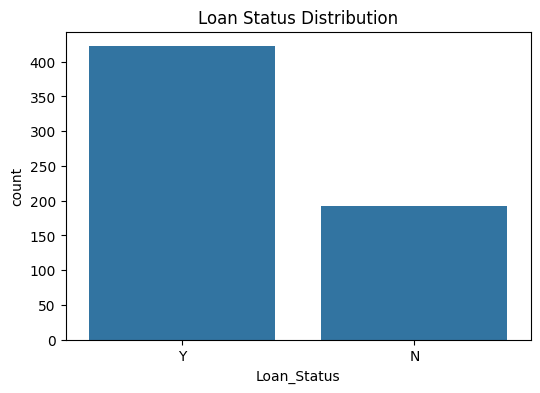

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()

### 2.2 Missing Values Analysis

Missing Values:
 Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


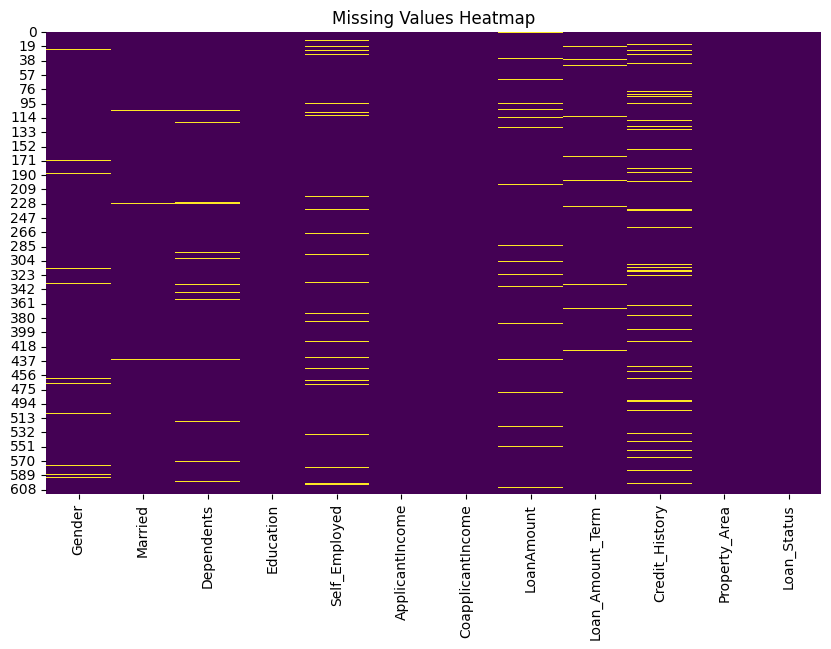

In [4]:
print("Missing Values:\n", df.isnull().sum())
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### 2.3 Distribution Plots for Numerical Features

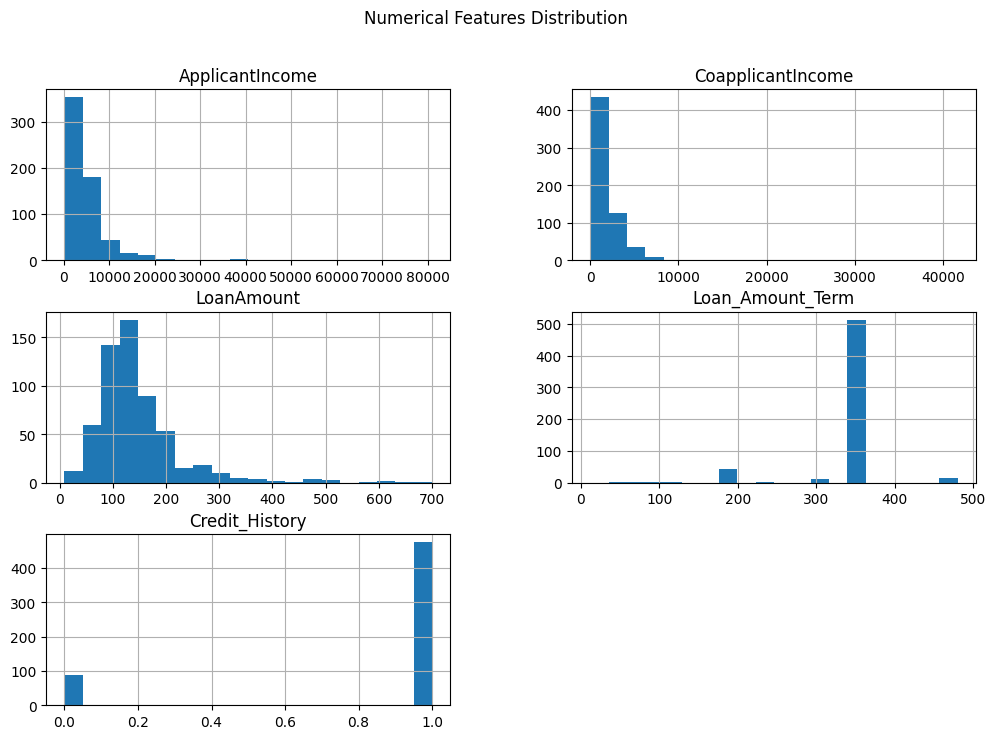

In [5]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
df[numerical_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle('Numerical Features Distribution')
plt.show()

## 3. Data Preprocessing
### 3.1 Handling Missing Values

In [6]:
# Numerical: median
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Categorical: mode
for col in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

### 3.2 Encoding Categorical Variables & Correlation Heatmap

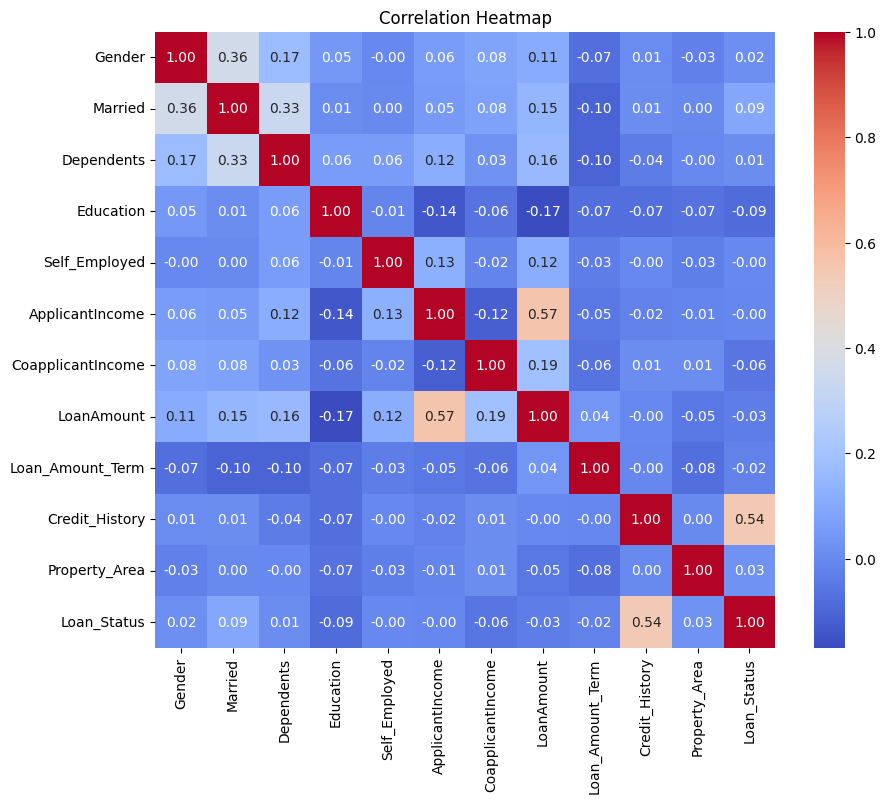

In [7]:
feature_columns = [
    'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
    'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
    'Credit_History', 'Property_Area'
]

encoders = {}
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

le_target = LabelEncoder()
df_encoded['Loan_Status'] = le_target.fit_transform(df_encoded['Loan_Status'])

X = df_encoded[feature_columns]
y = df_encoded['Loan_Status']

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### 3.3 Train/Test Split (Before Scaling to prevent Data Leakage)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f'Original Training size: {X_train.shape}, Test size: {X_test.shape}')

Original Training size: (411, 11), Test size: (203, 11)


### 3.4 Scaling and SMOTE (Applied ONLY to Training Data)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f'Balanced Training size: {X_train_bal.shape}')

Balanced Training size: (582, 11)


## 5. Model Training and Comparison

--- Decision Tree ---
Train Accuracy: 1.0000
Test Accuracy: 0.7192
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.62      0.56      0.58        72
           1       0.77      0.81      0.79       131

    accuracy                           0.72       203
   macro avg       0.69      0.68      0.69       203
weighted avg       0.71      0.72      0.72       203



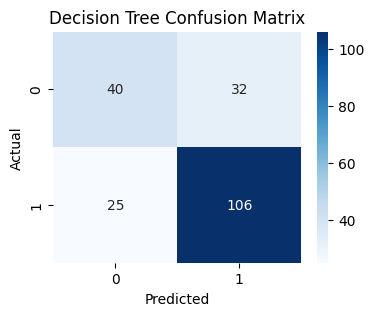

--- Random Forest ---
Train Accuracy: 1.0000
Test Accuracy: 0.7488
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.68      0.56      0.61        72
           1       0.78      0.85      0.81       131

    accuracy                           0.75       203
   macro avg       0.73      0.71      0.71       203
weighted avg       0.74      0.75      0.74       203



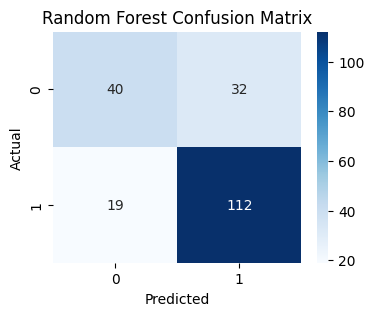

--- KNN ---
Train Accuracy: 0.8608
Test Accuracy: 0.6700
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.53      0.58      0.56        72
           1       0.76      0.72      0.74       131

    accuracy                           0.67       203
   macro avg       0.64      0.65      0.65       203
weighted avg       0.68      0.67      0.67       203



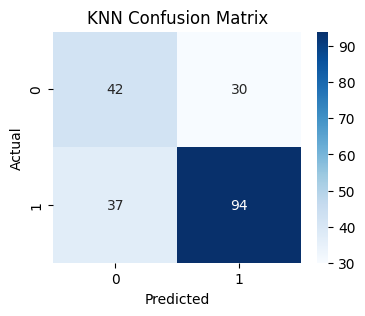

--- XGBoost ---
Train Accuracy: 1.0000
Test Accuracy: 0.7438
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.67      0.56      0.61        72
           1       0.78      0.85      0.81       131

    accuracy                           0.74       203
   macro avg       0.72      0.70      0.71       203
weighted avg       0.74      0.74      0.74       203



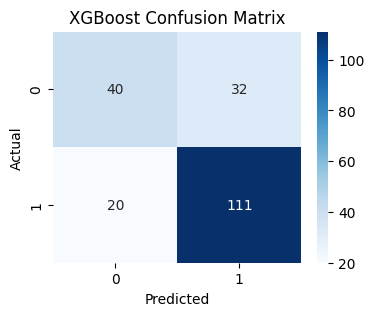


Best Model: Random Forest with accuracy 0.7488


In [10]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
best_model = None
best_accuracy = 0
best_model_name = ""

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_train_pred = model.predict(X_train_bal)
    y_test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train_bal, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    results[name] = test_acc
    
    print(f'--- {name} ---')
    print(f'Train Accuracy: {train_acc:.4f}')
    print(f'Test Accuracy: {test_acc:.4f}')
    print('Classification Report (Test):')
    print(classification_report(y_test, y_test_pred))
    
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        best_model = model
        best_model_name = name

print(f'\nBest Model: {best_model_name} with accuracy {best_accuracy:.4f}')

### 5.1 Accuracy Comparison Chart

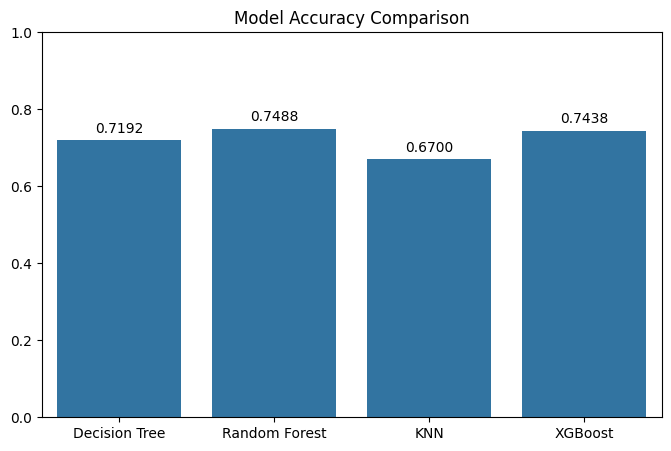

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.show()

### 5.2 Feature Importance (Best Model)

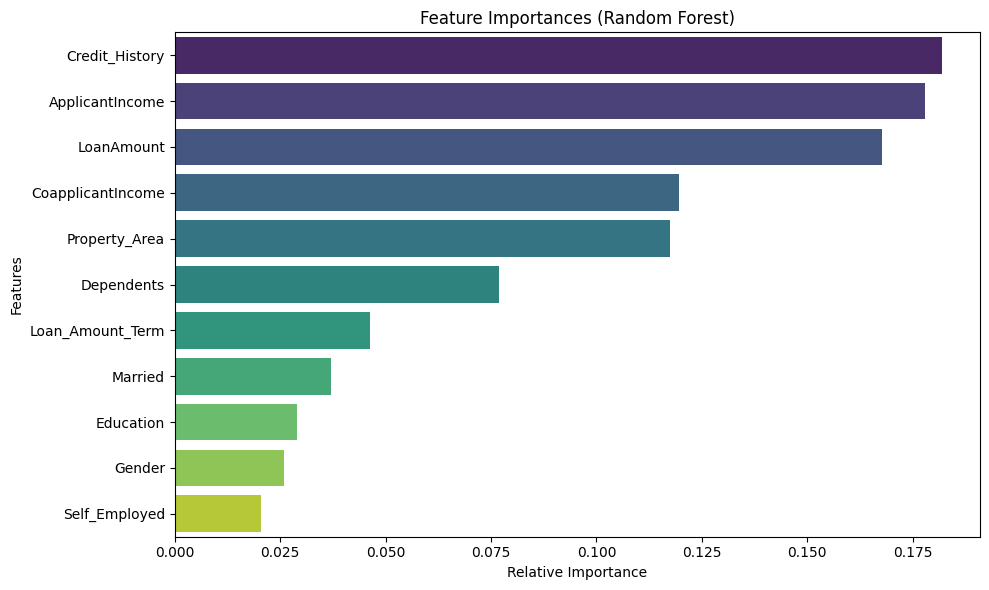

In [12]:
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(10,6))
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.title(f'Feature Importances ({best_model_name})')
    sns.barplot(x=importances[indices], y=[feature_columns[i] for i in indices], palette='viridis')
    plt.xlabel('Relative Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} does not support feature_importances_ directly.')

## 6. Export Models and Scaler

In [13]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(encoders, '../models/encoders.pkl')
joblib.dump(feature_columns, '../models/feature_columns.pkl')
print(f'Artifacts saved successfully for {best_model_name}.')

Artifacts saved successfully for Random Forest.


## 7. Conclusion
The data was carefully preprocessed to avoid data leakage by splitting the dataset before applying scaling and SMOTE. Various models were evaluated using train and test accuracy, classification reports, and confusion matrices. The selected model was automatically chosen based on the best test accuracy. All necessary artifacts (`best_model.pkl`, `scaler.pkl`, `encoders.pkl`, `feature_columns.pkl`) were successfully exported for deployment.